In [1]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# LOADING DATASET

df = pd.read_csv("car data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (301, 9)

Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [3]:
print("\nFirst 25 Rows:")
df.head(25)


First 25 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [4]:
print("\nLast 10 Rows:")
df.tail(10)


Last 10 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
291,brio,2015,5.40,6.10,31427,Petrol,Dealer,Manual,0
292,jazz,2016,6.40,8.40,12000,Petrol,Dealer,Manual,0
293,city,2010,3.25,9.90,38000,Petrol,Dealer,Manual,0
294,amaze,2014,3.75,6.80,33019,Petrol,Dealer,Manual,0
295,city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.90,5464,Petrol,Dealer,Manual,0


In [5]:
print("\nRandom 15 Samples:")
df.sample(15)


Random 15 Samples:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
253,city,2014,7.20,9.900,48000,Diesel,Dealer,Manual,0
212,creta,2016,11.25,13.600,22671,Petrol,Dealer,Manual,0
183,Bajaj Discover 100,2013,0.27,0.470,21000,Petrol,Individual,Manual,0
180,Hero Honda Passion Pro,2012,0.30,0.510,60000,Petrol,Individual,Manual,0
298,city,2009,3.35,11.000,87934,Petrol,Dealer,Manual,0
175,Hero Honda CBZ extreme,2011,0.38,0.787,75000,Petrol,Individual,Manual,0
53,fortuner,2013,16.00,30.610,135000,Diesel,Individual,Automatic,0
231,verna,2017,9.25,9.400,15001,Petrol,Dealer,Manual,0
281,city,2006,2.10,7.600,50456,Petrol,Dealer,Manual,0
80,corolla altis,2016,14.73,14.890,23000,Diesel,Dealer,Manual,0


In [6]:
# EXPLORING DATA

print("=== Dataset Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Fuel Type Distribution ===")
print(df['Fuel_Type'].value_counts())

print("\n=== Transmission Distribution ===")
print(df['Transmission'].value_counts())

print("\n=== Selling Type Distribution ===")
print(df['Selling_type'].value_counts())

=== Dataset Summary ===
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000

=== Missing Values ===
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

=== Fuel Type Distribution ===
Fuel_Type
Petrol    239
Diesel     60
CNG         2


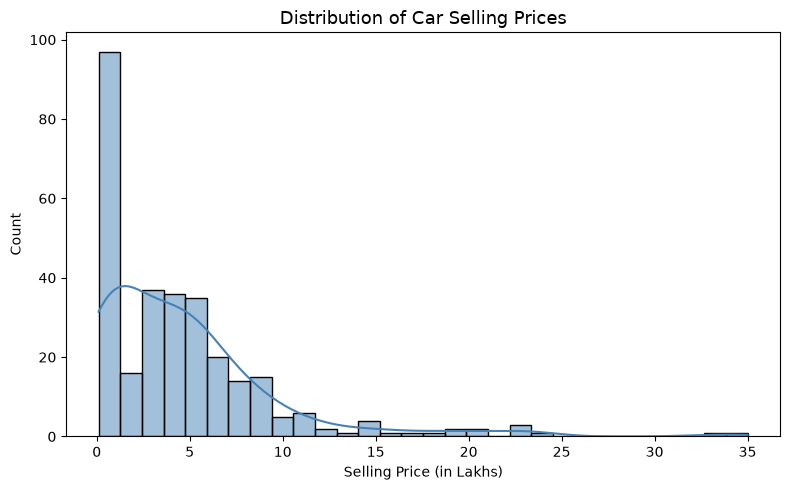

In [7]:
# Selling Price Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], bins=30, color='steelblue', kde=True)
plt.title('Distribution of Car Selling Prices', fontsize=13)
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

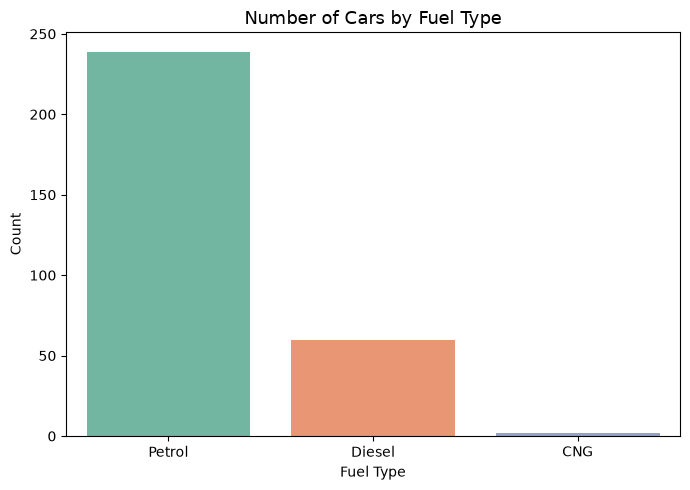

In [8]:
# Fuel Type Count 

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Fuel_Type', palette='Set2')
plt.title('Number of Cars by Fuel Type', fontsize=13)
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

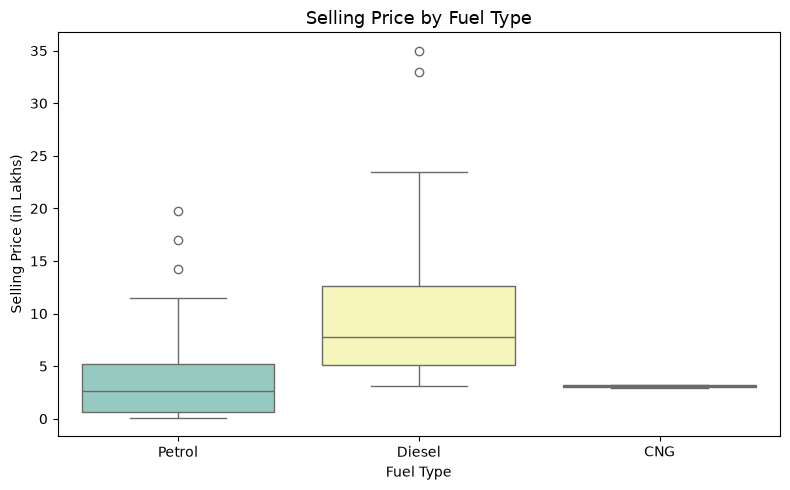

In [9]:
# Selling Price by Fuel Type 

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', palette='Set3')
plt.title('Selling Price by Fuel Type', fontsize=13)
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.tight_layout()
plt.show()

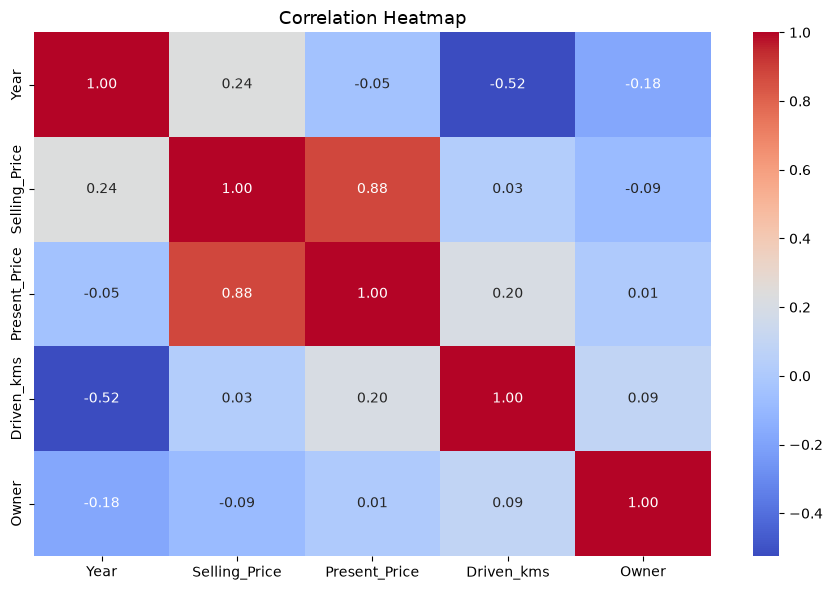

In [10]:
# Correlation Heatmap

plt.figure(figsize=(9, 6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

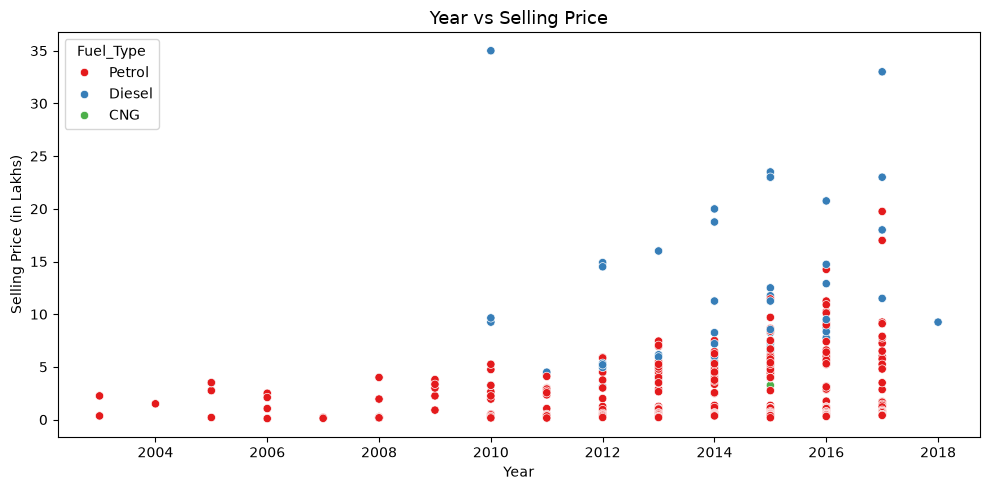

In [11]:
# Year vs Selling Price

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Year', y='Selling_Price',
                hue='Fuel_Type', palette='Set1')
plt.title('Year vs Selling Price', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Selling Price (in Lakhs)')
plt.tight_layout()
plt.show()

In [12]:
# Add car age feature

df['Car_Age'] = 2024 - df['Year']

# Encode categorical columns
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

print("After Encoding:")
df.head()

After Encoding:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,2,0,1,0,10
1,sx4,2013,4.75,9.54,43000,1,0,1,0,11
2,ciaz,2017,7.25,9.85,6900,2,0,1,0,7
3,wagon r,2011,2.85,4.15,5200,2,0,1,0,13
4,swift,2014,4.60,6.87,42450,1,0,1,0,10


In [13]:
# SPLITTING DATA

X = df.drop(['Selling_Price', 'Car_Name', 'Year'], axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\nFeatures used: {X.columns.tolist()}")

Training samples : 240
Testing samples  : 61

Features used: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [14]:
# TRAINING RANDOM FOREST MODEL

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [15]:
# EVALUATING MODEL

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.mean(np.abs(y_test - y_pred))

print("=" * 40)
print("      MODEL PERFORMANCE")
print("=" * 40)
print(f"R² Score  : {r2:.4f} ({r2*100:.2f}%)")
print(f"RMSE      : {rmse:.2f} Lakhs")
print(f"MAE       : {mae:.2f} Lakhs")
print("=" * 40)

      MODEL PERFORMANCE
R² Score  : 0.9599 (95.99%)
RMSE      : 0.96 Lakhs
MAE       : 0.64 Lakhs


In [16]:
# MODEL COMPARISON


lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = np.mean(np.abs(y_test - lr_pred))

print("=" * 40)
print("       MODEL COMPARISON")
print("=" * 40)
print(f"{'Metric':<10} {'Linear Reg':>12} {'Random Forest':>15}")
print("-" * 40)
print(f"{'R² Score':<10} {lr_r2:>12.4f} {r2:>15.4f}")
print(f"{'RMSE':<10} {lr_rmse:>12.2f} {rmse:>15.2f}")
print(f"{'MAE':<10} {lr_mae:>12.2f} {mae:>15.2f}")
print("=" * 40)

if r2 > lr_r2:
    print("\n✅ Random Forest performs BETTER than Linear Regression!")
else:
    print("\n✅ Linear Regression performs BETTER than Random Forest!")

       MODEL COMPARISON
Metric       Linear Reg   Random Forest
----------------------------------------
R² Score         0.8467          0.9599
RMSE               1.88            0.96
MAE                1.22            0.64

✅ Random Forest performs BETTER than Linear Regression!


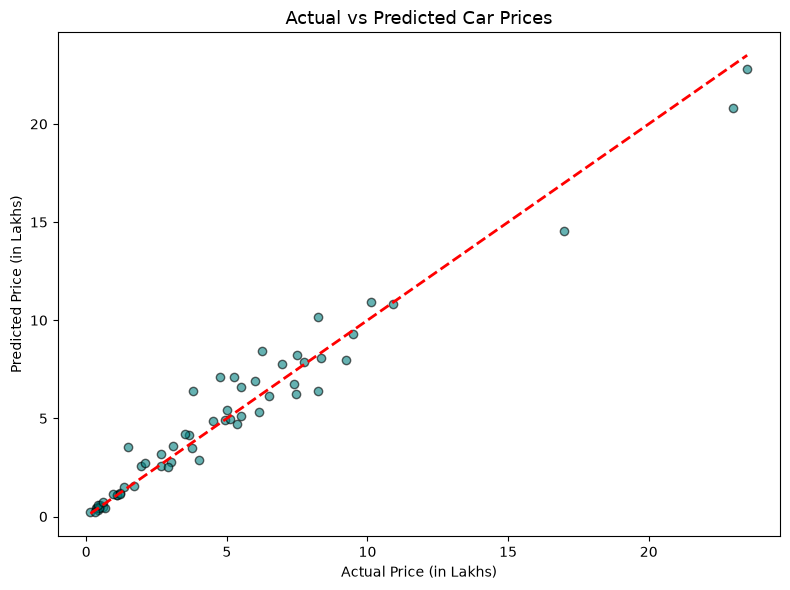

In [17]:
# Actual vs Predicted

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolors='black')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Car Prices', fontsize=13)
plt.xlabel('Actual Price (in Lakhs)')
plt.ylabel('Predicted Price (in Lakhs)')
plt.tight_layout()
plt.show()

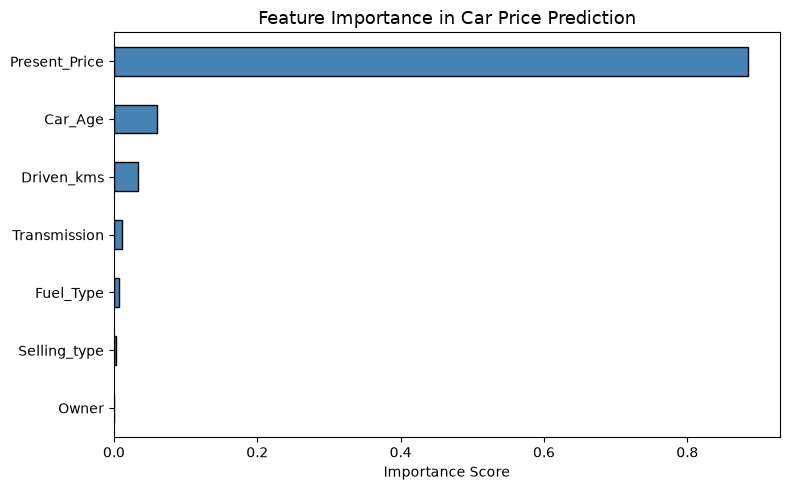


Top Feature: Present_Price


In [18]:
# FEATURE IMPORTANCE

features = X.columns
importances = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance in Car Price Prediction', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop Feature:", importances.idxmax())

In [19]:
# PREDICT A NEW CAR
# Columns: Present_Price, Driven_kms, Fuel_Type, Selling_type, Transmission, Owner, Car_Age

new_car = pd.DataFrame([[6.87, 20000, 1, 0, 0, 0, 6]],
                        columns=X.columns)

predicted_price = model.predict(new_car)
print(f"Predicted Selling Price: ₹ {predicted_price[0]:.2f} Lakhs")

Predicted Selling Price: ₹ 5.47 Lakhs
